# Attune — paper figures

Figure-generation notebook for the Attune writeup. Each section loads real demo
audio through the **live** DSP code in `algorithms/` (not a copy) so the figures
track the production algorithm.

## Prominence-based peak picking (pYIN frontend)

The YIN frontend of pYIN generates fundamental-period candidates as the
**topographically prominent** maxima of the (biased) autocorrelation
`r[τ] = Σ x[n]·x[n+τ]` — equivalently, the troughs of the CMNDF `d'(τ)`.

SciPy's prominence (`scipy.signal.peak_prominences`) is the vertical distance
between a peak and its *lowest contour line*: extend a level line left/right from
the peak until it meets higher ground (or the border); the minimum on each side
is a **base**; the **higher** base is the lowest contour line, and

$$\mathcal{P}(p) = r[p] - \max(\beta_L,\ \beta_R).$$

Because prominence is measured relative to the local saddle rather than the
origin, candidate selection is invariant to the lag-dependent decay of the
biased ACF envelope — it does not become biased against low-pitch (long-period)
candidates.

**Cite:** SciPy (Virtanen et al., *Nature Methods* 2020) + the
`scipy.signal.peak_prominences` reference manual entry.


In [1]:
# autoreload the live algorithms/ code when edited
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
sys.path.append('..')   # run from notebooks/, import repo packages


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import peak_prominences
import librosa

from algorithms.Config import Config
from algorithms.PitchDetector import PitchDetector

AUDIO = "../resources/demo/fugue/fugue_rec.mp3"
FRAME_TIME = 4.0   # seconds into the recording

# load mono @ the app's sample rate, build the live pitch detector
y, sr = librosa.load(AUDIO, sr=44100, mono=True)
config = Config()                      # production defaults (w1=4096, h1=128, ...)
pd = PitchDetector(config=config)

# one analysis frame's worth of audio, preprocessed exactly as the app does
start = int(FRAME_TIME * sr)
frame = y[start:start + config.w1]
x, vol = pd.preprocess_audio(frame)

# the frontend, step by step
acf, _  = pd.autocorrelation_fft(x)    # biased autocorrelation r[τ]
cdf     = pd.cmndf(x, acf)             # CMNDF d'(τ)
peaks   = pd.find_acf_peaks(acf)       # prominence-picked period candidates
prom, lb, rb = peak_prominences(acf, peaks)     # SciPy prominence + bases
probs, unv   = pd.pitch_probabilities(peaks, cdf)
best = peaks[int(np.argmax(probs))]

def tau_to_hz(t): return sr / t if t else np.nan
def note(t):      return Config.get_note_name(config.freq_to_midi(sr / t))

print(f"frame @ {FRAME_TIME:.1f}s  volume={vol:.3f}  candidates(τ)={list(peaks)}")
for pk, pr in zip(peaks, prom):
    print(f"  τ={pk:3d}  {tau_to_hz(pk):6.1f} Hz  {note(pk):>3}  prominence={pr:7.1f}")
print(f"picked f0 ≈ {tau_to_hz(best):.1f} Hz ({note(best)}),  unvoiced_prob={unv:.3f}")


frame @ 4.0s  volume=0.073  candidates(τ)=[74, 148, 225]
  τ= 74   595.9 Hz   D5  prominence=  600.3
  τ=148   298.0 Hz   D4  prominence=  527.0
  τ=225   196.0 Hz   G3  prominence=  382.0
picked f0 ≈ 595.9 Hz (D5),  unvoiced_prob=0.327


/Users/sarah/Desktop/shasha/Attune/at-venv/lib/python3.12/site-packages/resampy/filters.py:50: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


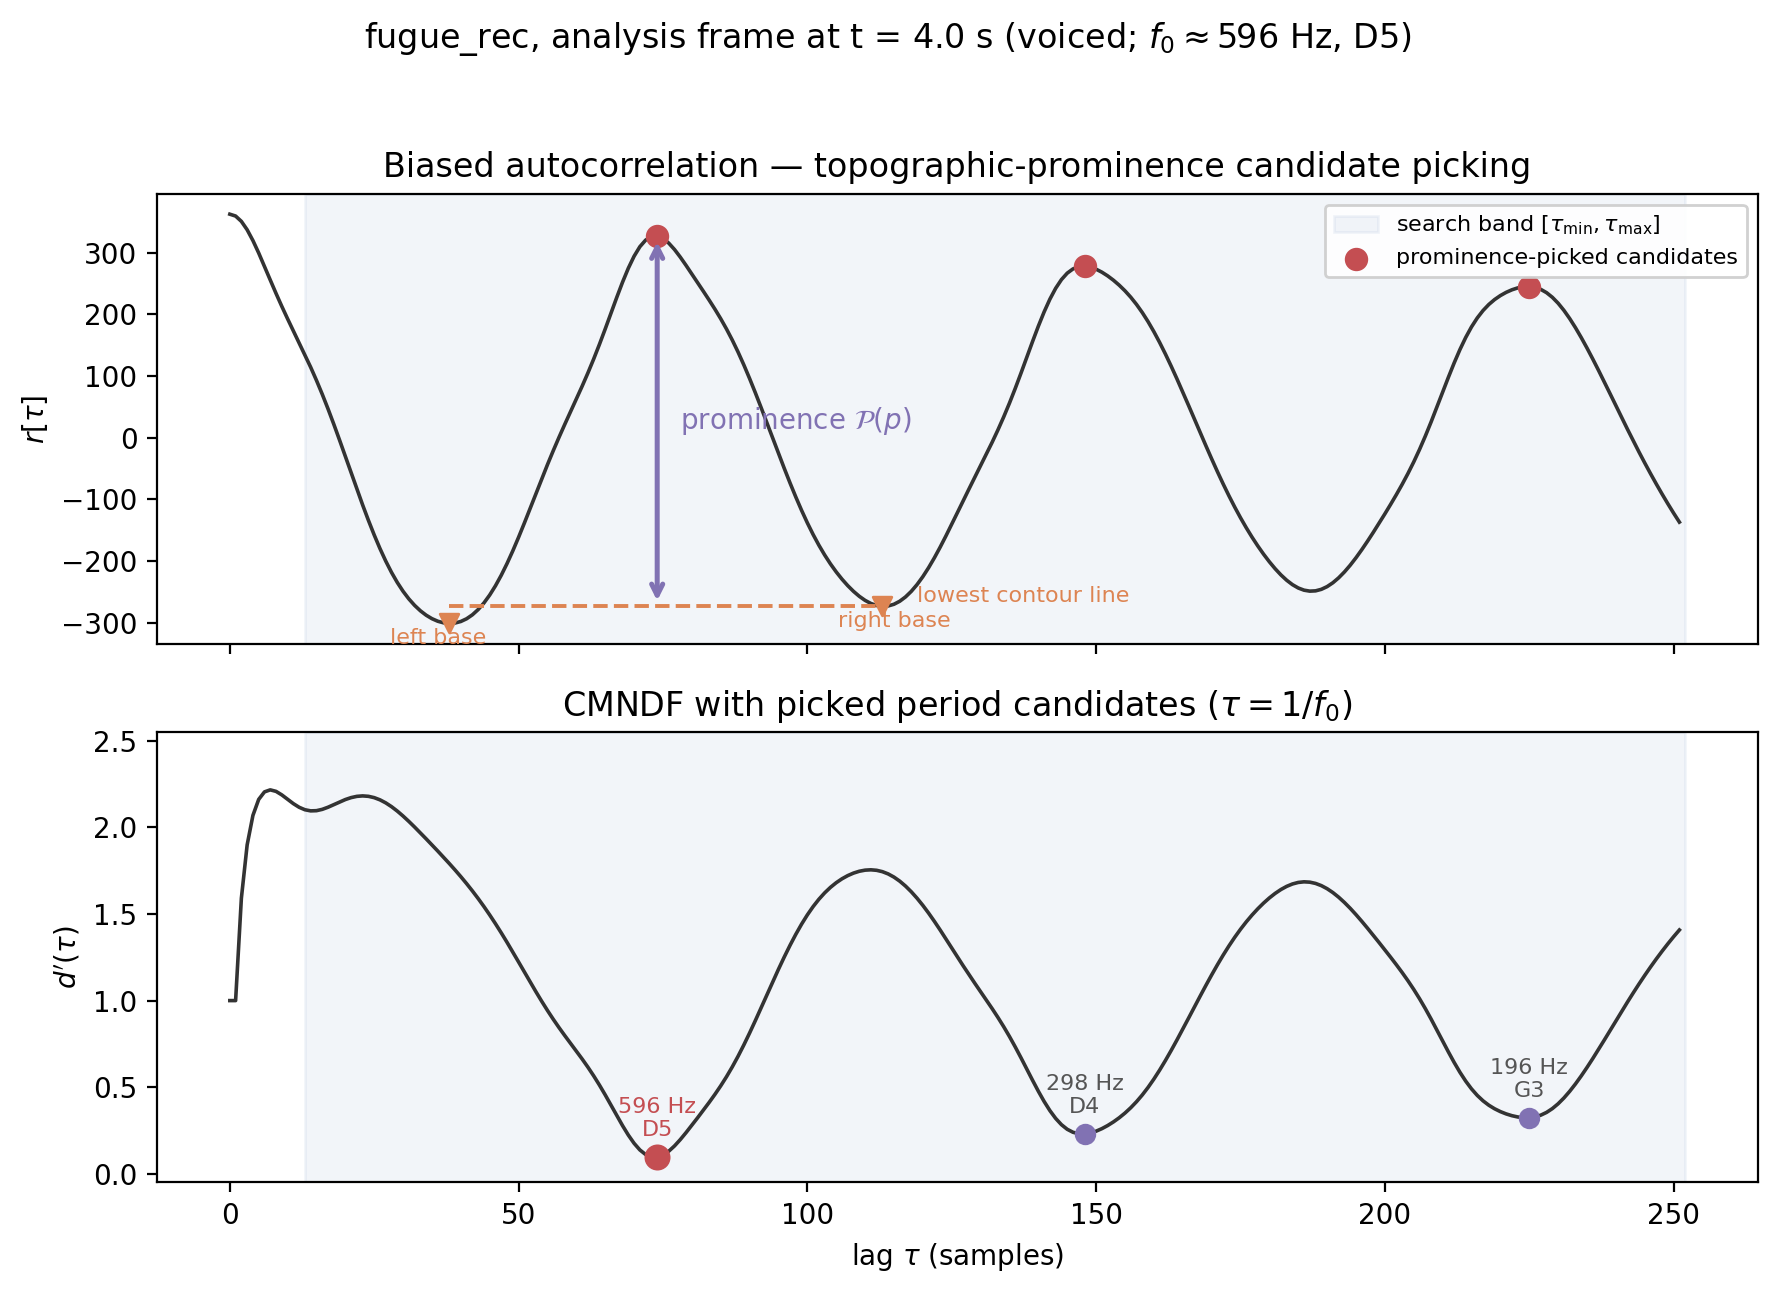

In [3]:
tau = np.arange(len(acf))
idx = {pk: i for i, pk in enumerate(peaks)}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)

# --- Panel A: ACF + prominence geometry for the picked f0 ---
ax1.plot(tau, acf, color="#333", lw=1.3, zorder=2)
ax1.axvspan(pd.tau_min, pd.tau_max, color="#4C72B0", alpha=0.07, zorder=0,
            label=r"search band $[\tau_{\min},\tau_{\max}]$")
ax1.scatter(peaks, acf[peaks], color="#C44E52", s=55, zorder=4,
            label="prominence-picked candidates")

p = best
li, ri = lb[idx[p]], rb[idx[p]]
contour = max(acf[li], acf[ri])                 # higher base = lowest contour line
ax1.plot([li, ri], [contour, contour], ls="--", color="#DD8452", lw=1.4, zorder=3)
ax1.scatter([li, ri], [acf[li], acf[ri]], marker="v", color="#DD8452", s=45, zorder=4)
ax1.annotate("", xy=(p, acf[p]), xytext=(p, contour),
             arrowprops=dict(arrowstyle="<->", color="#8172B3", lw=1.8), zorder=5)
ax1.text(p + 4, (acf[p] + contour) / 2, r"prominence $\mathcal{P}(p)$",
         color="#8172B3", va="center", fontsize=10)
ax1.text(li - 2, acf[li] - 8, "left base", color="#DD8452", va="top", ha="center", fontsize=8)
ax1.text(ri + 2, acf[ri] - 8, "right base", color="#DD8452", va="top", ha="center", fontsize=8)
ax1.text(ri + 6, contour, "lowest contour line", color="#DD8452", va="bottom", fontsize=8)
ax1.set_ylabel(r"$r[\tau]$")
ax1.set_title("Biased autocorrelation — topographic-prominence candidate picking")
ax1.legend(loc="upper right", fontsize=8, framealpha=0.9)

# --- Panel B: CMNDF with the same candidates as troughs ---
ax2.plot(tau, cdf, color="#333", lw=1.3, zorder=2)
ax2.axvspan(pd.tau_min, pd.tau_max, color="#4C72B0", alpha=0.07, zorder=0)
for pk in peaks:
    is_best = (pk == best)
    ax2.scatter([pk], [cdf[pk]], color="#C44E52" if is_best else "#8172B3",
                s=70 if is_best else 45, zorder=4)
    ax2.annotate(f"{tau_to_hz(pk):.0f} Hz\n{note(pk)}", xy=(pk, cdf[pk]),
                 xytext=(pk, cdf[pk] + 0.12), ha="center", fontsize=8,
                 color="#C44E52" if is_best else "#555")
ax2.set_xlabel(r"lag $\tau$ (samples)")
ax2.set_ylabel(r"$d'(\tau)$")
ax2.set_title(r"CMNDF with picked period candidates ($\tau = 1/f_0$)")
ax2.set_ylim(-0.05, cdf.max() * 1.15)

fig.suptitle(f"fugue_rec, analysis frame at t = {FRAME_TIME:.1f} s "
             f"(voiced; $f_0\\approx${tau_to_hz(best):.0f} Hz, {note(best)})",
             fontsize=12, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("fig_prominence_peakpicking.png", dpi=160, bbox_inches="tight")
plt.show()
